load data (yahoo finance -> pandas)

In [70]:
import pandas as pd
from time_series_forecasting.data.ingestion.yahoo_finance import load_yahoo_finance_data

data = load_yahoo_finance_data(
    ticker="AAPL",
    start_date="2024-01-01",
    end_date="2025-12-31"
)

# Ensure date index
data = data.sort_index()
data.head()


,Adj Close,Close,High,Low,Open,Volume
date,,,,,,
2024-01-02,183.903214,185.639999,188.440002,183.889999,187.149994,82488700
2024-01-03,182.526230,184.250000,185.880005,183.429993,184.220001,58414500
2024-01-04,180.208145,181.910004,183.089996,180.880005,182.149994,71983600
2024-01-05,179.484924,181.179993,182.759995,180.169998,181.990005,62379700
2024-01-08,183.823959,185.559998,185.600006,181.500000,182.089996,59144500


Convert to DART `TimeSeries`

<Axes: xlabel='date'>

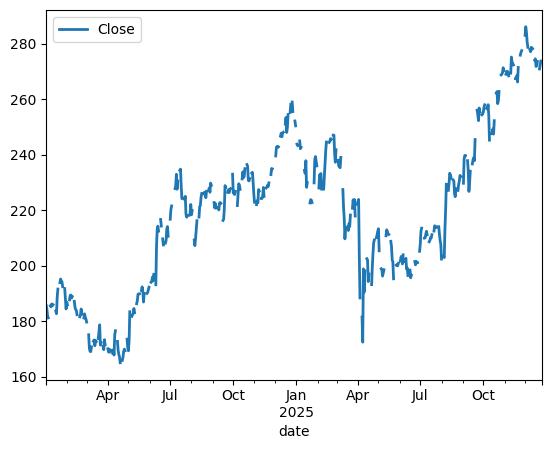

In [73]:
from darts import TimeSeries

data_reset = data.reset_index()

series = TimeSeries.from_dataframe(
    df=data_reset,
    time_col="date",
    value_cols=["Close"],
    freq="D"
)

series.plot()


Hnadle Missing Values

<Axes: xlabel='date'>

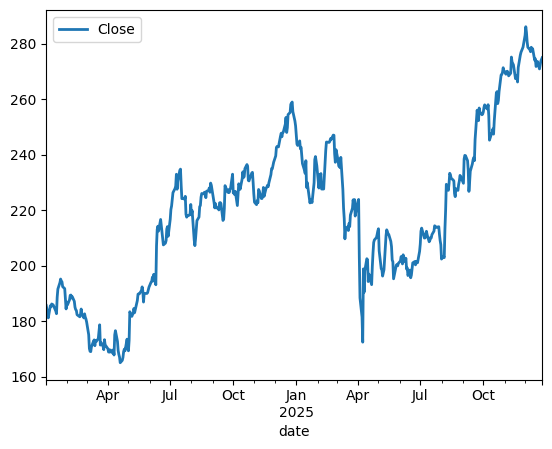

In [75]:
from darts.utils.missing_values import fill_missing_values

series_filled = fill_missing_values(
    series = series,
    method = 'linear'
)

series_filled.plot()

Scale Target Series (DL Safe)

In [77]:
from darts.dataprocessing.transformers import Scaler

# by default Darts uses min-max scaler
target_scaler = Scaler()
series_scaled = target_scaler.fit_transform(series_filled)


'''
how ever we can other scaler functions from sklean and apply
this is becuase darts does not have scaler method by itself

from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
target_scaler = Scalar(std_scaler)
sereis_scaled = target_scaler.fit_transform(series_filled)

'''

'\nhow ever we can other scaler functions from sklean and apply\nthis is becuase darts does not have scaler method by itself\n\nfrom sklearn.preprocessing import StandardScaler\n\nstd_scaler = StandardScaler()\ntarget_scaler = Scalar(std_scaler)\nsereis_scaled = target_scaler.fit_transform(series_filled)\n\n'

Baseline Model  - Naive Seasonal

<Axes: xlabel='date'>

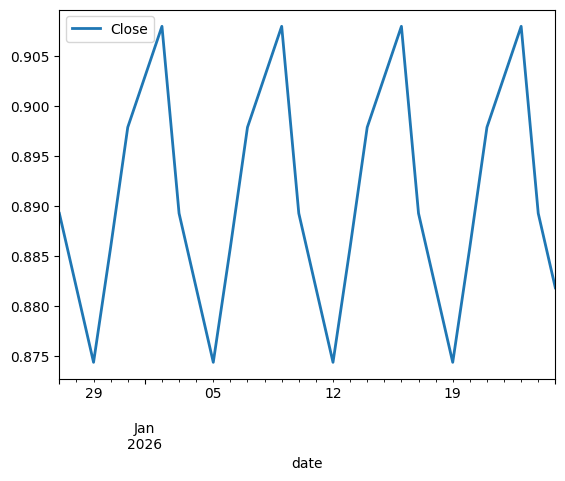

In [78]:
from darts.models import NaiveSeasonal

naive_model = NaiveSeasonal(K = 7)
naive_model.fit(series_scaled)

forecast_naive = naive_model.predict(30)
forecast_naive.plot()


Baseline Model - Exponential Smoothing

<Axes: xlabel='date'>

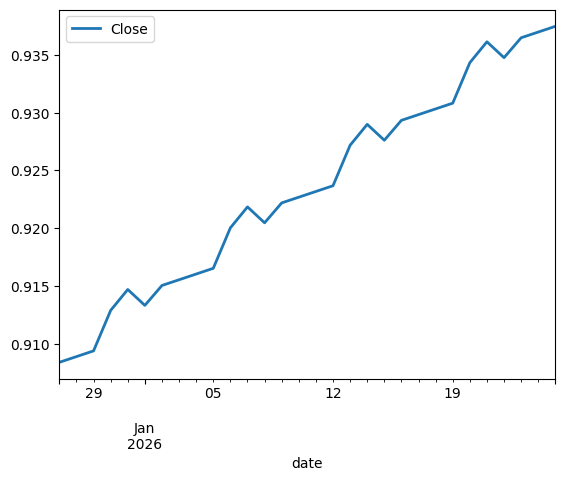

In [80]:
from darts.models import ExponentialSmoothing

hw_model = ExponentialSmoothing()
hw_model.fit(series_scaled)

forecast_hw = hw_model.predict(30)
forecast_hw.plot()

```python
Examples:

from darts.datasets import AirPassengersDataset
from darts.models import ExponentialSmoothing
from darts.utils.utils import ModelMode, SeasonalityMode

series = AirPassengersDataset().load()
# using Holt's exponential smoothing
model = ExponentialSmoothing(trend=ModelMode.ADDITIVE, seasonal=SeasonalityMode.MULTIPLICATIVE)
model.fit(series)
pred = model.predict(6)
print(pred.values())
```

Proper Evaluation via Backtesting (NO train / test split)

In [86]:
from darts.metrics import mape, wmape, mae, rmse

'''
print(
    "MAPE:",
    hw_model.backtest(
        series=series_scaled,
        forecast_horizon=30,
        stride=7,
        metric=mape
    )
)
'''

print(
    "WMAPE:",
    hw_model.backtest(
        series=series_scaled,
        forecast_horizon=30,
        stride=7,
        metric=wmape
    )
)

print(
    "MAE:",
    hw_model.backtest(
        series=series_scaled,
        forecast_horizon=30,
        stride=7,
        metric=mae
    )
)

print(
    "RMSE:",
    hw_model.backtest(
        series=series_scaled,
        forecast_horizon=30,
        stride=7,
        metric=rmse
    )
)


WMAPE: 25.248621002258034
MAE: 0.07946968583347429
RMSE: 0.09196525886150178


Create a full time index (history + forecast horizon)

In [100]:
import pandas as pd

forecast_horizon = 30

full_time_index = pd.date_range(
    start=series.time_index[0],
    end=series.time_index[-1] + pd.Timedelta(days=forecast_horizon),
    freq="D"
)

## claender Feature Engineering (Feature Covariates)

dayofweek → one-hot

In [101]:
from darts.utils.timeseries_generation import datetime_attribute_timeseries

dayofweek_full = datetime_attribute_timeseries(
    full_time_index,
    attribute="dayofweek",
    one_hot=True
)

month -> one-hot

In [102]:
month_full = datetime_attribute_timeseries(
    full_time_index,
    attribute="month",
    one_hot=True
)


day_of_year-> Numeric

In [103]:
day_of_year_full = datetime_attribute_timeseries(
    full_time_index,
    attribute="dayofyear",
    one_hot=False
)


is_weekend -> binary

In [104]:
import numpy as np
from darts import TimeSeries

is_weekend_full = TimeSeries.from_times_and_values(
    times=full_time_index,
    values=(full_time_index.weekday >= 5)
           .astype(int)
           .reshape(-1, 1),
    columns=["is_weekend"]
)

Combine Calender Feature

In [105]:
future_covariates_full = (
    dayofweek_full
    .stack(month_full)
    .stack(day_of_year_full)
    .stack(is_weekend_full)
)


Split covariates into TRAIN and FUTURE parts

In [108]:
future_covariates_train = future_covariates_full.slice_intersect(series)
future_covariates_train


,dayofweek_0,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,...,month_9,month_10,month_11,dayofyear,is_weekend
2024-01-02,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0
2024-01-03,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.0
2024-01-04,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,3.0,0.0
2024-01-05,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,4.0,0.0
2024-01-06,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-22,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,355.0,0.0
2025-12-23,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,356.0,0.0
2025-12-24,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,357.0,0.0
2025-12-25,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,358.0,0.0


cale covariates (correct & leakage-safe)

In [107]:
from darts.dataprocessing.transformers import Scaler

covariate_scaler = Scaler()

future_covariates_train_scaled = covariate_scaler.fit_transform(
    future_covariates_train
)

future_covariates_full_scaled = covariate_scaler.transform(
    future_covariates_full
)


Build a RegressionModel with covariates

In [122]:
# Build a RegressionModel with covariates

from darts.models import RegressionModel
from sklearn.ensemble import GradientBoostingRegressor

reg_model = RegressionModel(
    model=GradientBoostingRegressor(random_state=42),
    lags=30,
    lags_future_covariates=[0, 7, 14]
)


# Fit with future covariates (NOW this is valid)
reg_model.fit(
    series_scaled,
    future_covariates=future_covariates_train_scaled
)

# Forecast with full covariates
forecast = reg_model.predict(
    n=forecast_horizon,
    future_covariates=future_covariates_full_scaled
)


# Inverse scale for metrics
forecast_inv = target_scaler.inverse_transform(forecast)


ValueError: The `future_covariates` are not long enough. Given horizon `n=30`, `min(lags_future_covariates)=0`, `max(lags_future_covariates)=14` and `output_chunk_length=1`, the `future_covariates` have to range from 2025-12-27 00:00:00 until 2026-02-08 00:00:00 (inclusive), but they only range from 2024-01-02 00:00:00 until 2026-01-25 00:00:00.


ValueError: The `future_covariates` are not long enough. Given horizon `n=30`, `min(lags_future_covariates)=0`, `max(lags_future_covariates)=14` and `output_chunk_length=1`, the `future_covariates` have to range from 2025-12-27 00:00:00 until 2026-02-08 00:00:00 (inclusive), but they only range from 2024-01-02 00:00:00 until 2026-01-25 00:00:00.

In [120]:
forecast = reg_model.predict(
    n=forecast_horizon,
    future_covariates=future_covariates_full_scaled
)


ValueError: The `future_covariates` are not long enough. Given horizon `n=30`, `min(lags_future_covariates)=0`, `max(lags_future_covariates)=14` and `output_chunk_length=1`, the `future_covariates` have to range from 2025-12-27 00:00:00 until 2026-02-08 00:00:00 (inclusive), but they only range from 2024-01-02 00:00:00 until 2026-01-25 00:00:00.


ValueError: The `future_covariates` are not long enough. Given horizon `n=30`, `min(lags_future_covariates)=0`, `max(lags_future_covariates)=14` and `output_chunk_length=1`, the `future_covariates` have to range from 2025-12-27 00:00:00 until 2026-02-08 00:00:00 (inclusive), but they only range from 2024-01-02 00:00:00 until 2026-01-25 00:00:00.

In [121]:
forecast_inv = target_scaler.inverse_transform(forecast)


---
---


<Axes: xlabel='date'>

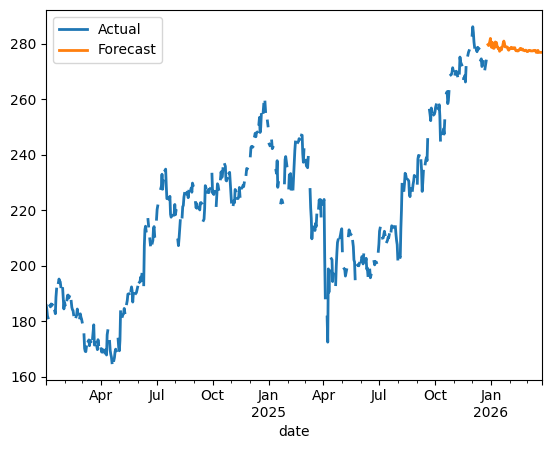

In [125]:
# ============================================================
# 1️⃣ IMPORTS
# ============================================================

import pandas as pd
import numpy as np

from darts import TimeSeries
from darts.utils.missing_values import fill_missing_values
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import SKLearnModel
from sklearn.ensemble import GradientBoostingRegressor

# ------------------------------------------------------------
# (Assumed) Custom data loader
# ------------------------------------------------------------
from time_series_forecasting.data.ingestion.yahoo_finance import (
    load_yahoo_finance_data
)

# ============================================================
# 2️⃣ LOAD DATA (Yahoo Finance)
# ============================================================

# Load daily OHLC data for Apple
data = load_yahoo_finance_data(
    ticker="AAPL",
    start_date="2024-01-01",
    end_date="2025-12-31"
)

# Ensure data is sorted by time
data = data.sort_index()

# ============================================================
# 3️⃣ CONVERT TO DARTS TimeSeries
# ============================================================

# Reset index so date becomes a column
data_reset = data.reset_index()

# Create a DARTS TimeSeries using Close price
series = TimeSeries.from_dataframe(
    df=data_reset,
    time_col="date",
    value_cols=["Close"],
    freq="D"
)

# ============================================================
# 4️⃣ HANDLE MISSING VALUES
# ============================================================

# Fill missing timestamps / values using linear interpolation
series_filled = fill_missing_values(
    series,
    method="linear"
)

# ============================================================
# 5️⃣ SCALE TARGET SERIES (MANDATORY FOR ML/DL)
# ============================================================

# Create scaler for target series
target_scaler = Scaler()

# Fit on historical data only and transform
series_scaled = target_scaler.fit_transform(series_filled)

# ============================================================
# 6️⃣ DEFINE FORECAST SETTINGS
# ============================================================

forecast_horizon = 90              # Predict next 30 days
lags_target = 180                   # Use last 30 days of target
lags_future_covariates = [0, 7, 14]  # Use known future signals

# Maximum future lag required
max_future_lag = max(lags_future_covariates)

# Total future days needed for covariates
required_future_days = forecast_horizon + max_future_lag

# ============================================================
# 7️⃣ BUILD FULL TIME INDEX (PAST + FUTURE)
# ============================================================

full_time_index = pd.date_range(
    start=series.time_index[0],
    end=series.time_index[-1] + pd.Timedelta(days=required_future_days),
    freq="D"
)

# ============================================================
# 8️⃣ CREATE CALENDAR FUTURE COVARIATES
# ============================================================

# --- Day of week (one-hot) ---
dayofweek = datetime_attribute_timeseries(
    full_time_index,
    attribute="dayofweek",
    one_hot=True
)

# --- Month (one-hot) ---
month = datetime_attribute_timeseries(
    full_time_index,
    attribute="month",
    one_hot=True
)

# --- Day of year (numeric, continuous) ---
day_of_year = datetime_attribute_timeseries(
    full_time_index,
    attribute="dayofyear",
    one_hot=False
)

# --- Weekend flag (binary) ---
is_weekend = TimeSeries.from_times_and_values(
    times=full_time_index,
    values=(full_time_index.weekday >= 5)
           .astype(int)
           .reshape(-1, 1),
    columns=["is_weekend"]
)

# ============================================================
# 9️⃣ COMBINE ALL FUTURE COVARIATES
# ============================================================

future_covariates_full = (
    dayofweek
    .stack(month)
    .stack(day_of_year)
    .stack(is_weekend)
)

# ============================================================
# 🔟 SPLIT FUTURE COVARIATES (TRAIN PART ONLY)
# ============================================================

# Align covariates exactly with target series timeline
future_covariates_train = future_covariates_full.slice_intersect(
    series
)

# ============================================================
# 1️⃣1️⃣ SCALE FUTURE COVARIATES (NO LEAKAGE)
# ============================================================

# Create separate scaler for covariates
covariate_scaler = Scaler()

# Fit ONLY on historical covariates
future_covariates_train_scaled = covariate_scaler.fit_transform(
    future_covariates_train
)

# Transform full (history + future)
future_covariates_full_scaled = covariate_scaler.transform(
    future_covariates_full
)

# ============================================================
# 1️⃣2️⃣ BUILD SKLEARN MODEL (ENTERPRISE SAFE)
# ============================================================

reg_model = SKLearnModel(
    model=GradientBoostingRegressor(random_state=42),
    lags=lags_target,
    lags_future_covariates=lags_future_covariates,
    output_chunk_length=1
)

# ============================================================
# 1️⃣3️⃣ TRAIN MODEL
# ============================================================

reg_model.fit(
    series=series_scaled,
    future_covariates=future_covariates_train_scaled
)

# ============================================================
# 1️⃣4️⃣ FORECAST
# ============================================================

forecast_scaled = reg_model.predict(
    n=forecast_horizon,
    future_covariates=future_covariates_full_scaled
)

# ============================================================
# 1️⃣5️⃣ INVERSE SCALE FORECAST (BUSINESS SCALE)
# ============================================================

forecast = target_scaler.inverse_transform(
    forecast_scaled
)

# ============================================================
# 1️⃣6️⃣ VISUALIZE RESULT
# ============================================================

series.plot(label="Actual")
forecast.plot(label="Forecast")


---
---

In [ ]:
# ============================================================
# 1️⃣ IMPORTS
# ============================================================

import pandas as pd
import numpy as np

from darts import TimeSeries
from darts.utils.missing_values import fill_missing_values
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler

from darts.models import TFTModel
from darts.utils.likelihood_models import QuantileRegression
from darts.metrics import mape, rmse

# Custom Yahoo Finance loader
from time_series_forecasting.data.ingestion.yahoo_finance import (
    load_yahoo_finance_data
)

# ============================================================
# 2️⃣ LOAD DATA
# ============================================================

data = load_yahoo_finance_data(
    ticker="AAPL",
    start_date="2024-01-01",
    end_date="2025-12-31"
).sort_index()

# ============================================================
# 3️⃣ CREATE DARTS TIMESERIES
# ============================================================

series = TimeSeries.from_dataframe(
    data.reset_index(),
    time_col="date",
    value_cols=["Close"],
    freq="D"
)

# ============================================================
# 4️⃣ HANDLE MISSING VALUES
# ============================================================

series_filled = fill_missing_values(series, method="linear")

# ============================================================
# 5️⃣ SCALE TARGET (MANDATORY FOR TFT)
# ============================================================

target_scaler = Scaler()
series_scaled = target_scaler.fit_transform(series_filled)

# ============================================================
# 6️⃣ FORECAST SETTINGS
# ============================================================

forecast_horizon = 30
input_chunk_length = 90
output_chunk_length = 30

# ============================================================
# 7️⃣ BUILD FULL TIME INDEX FOR FUTURE COVARIATES
# ============================================================

full_time_index = pd.date_range(
    start=series.time_index[0],
    end=series.time_index[-1] + pd.Timedelta(days=forecast_horizon),
    freq="D"
)

# ============================================================
# 8️⃣ CALENDAR FUTURE COVARIATES
# ============================================================

dayofweek = datetime_attribute_timeseries(
    full_time_index, "dayofweek", one_hot=True
)

month = datetime_attribute_timeseries(
    full_time_index, "month", one_hot=True
)

day_of_year = datetime_attribute_timeseries(
    full_time_index, "dayofyear", one_hot=False
)

is_weekend = TimeSeries.from_times_and_values(
    full_time_index,
    (full_time_index.weekday >= 5).astype(int).reshape(-1, 1),
    columns=["is_weekend"]
)

future_covariates_full = (
    dayofweek.stack(month)
              .stack(day_of_year)
              .stack(is_weekend)
)

# ============================================================
# 9️⃣ ALIGN & SCALE FUTURE COVARIATES (NO LEAKAGE)
# ============================================================

future_covariates_train = future_covariates_full.slice_intersect(series)

cov_scaler = Scaler()

future_covariates_train_scaled = cov_scaler.fit_transform(
    future_covariates_train
)

future_covariates_full_scaled = cov_scaler.transform(
    future_covariates_full
)

# ============================================================
# 🔟 BUILD TFT MODEL (ENTERPRISE CONFIG)
# ============================================================

tft = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,

    hidden_size=64,
    lstm_layers=1,
    num_attention_heads=4,
    dropout=0.1,

    batch_size=32,
    n_epochs=50,
    optimizer_kwargs={"lr": 1e-3},

    likelihood=QuantileRegression(
        quantiles=[0.1, 0.5, 0.9]
    ),

    random_state=42,
    force_reset=True
)

# ============================================================
# 1️⃣1️⃣ TRAIN TFT MODEL
# ============================================================

tft.fit(
    series=series_scaled,
    future_covariates=future_covariates_train_scaled,
    verbose=True
)

# ============================================================
# 1️⃣2️⃣ FORECAST
# ============================================================

forecast_scaled = tft.predict(
    n=forecast_horizon,
    future_covariates=future_covariates_full_scaled
)

forecast = target_scaler.inverse_transform(forecast_scaled)

# ============================================================
# 1️⃣3️⃣ ROLLING BACKTESTING (ENTERPRISE STANDARD)
# ============================================================

bt_mape = tft.backtest(
    series=series_filled,                   # use original scale for metrics
    future_covariates=future_covariates_full_scaled,
    forecast_horizon=forecast_horizon,
    stride=7,
    retrain=True,
    metric=mape
)

bt_rmse = tft.backtest(
    series=series_filled,
    future_covariates=future_covariates_full_scaled,
    forecast_horizon=forecast_horizon,
    stride=7,
    retrain=True,
    metric=rmse
)

print(f"Rolling Backtest MAPE: {bt_mape:.3f}")
print(f"Rolling Backtest RMSE: {bt_rmse:.3f}")

# ============================================================
# 1️⃣4️⃣ TFT EXPLAINABILITY
# ============================================================

# Explain last prediction window
explanation = tft.explain_prediction(
    series=series_scaled,
    future_covariates=future_covariates_train_scaled
)

# Plot attention-based variable importance
explanation.plot_variable_importance()

# ============================================================
# 1️⃣5️⃣ VISUALIZATION
# ============================================================

series.plot(label="Actual")
forecast.quantile_timeseries(0.5).plot(label="Forecast P50")
forecast.quantile_timeseries(0.1).plot(label="Forecast P10")
forecast.quantile_timeseries(0.9).plot(label="Forecast P90")


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 42.8 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 40.7 K | train
6  | static_context_grn                | _GatedResidualNetwork            | 16.8 K | train
7  | static_context_hidden_encoder_grn | _GatedResidualNetwork 

Epoch 49: 100%|██████████| 19/19 [00:16<00:00,  1.12it/s, train_loss=0.0263]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 19/19 [00:16<00:00,  1.12it/s, train_loss=0.0263]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Epoch 49: 100%|██████████| 9/9 [00:05<00:00,  1.63it/s, train_loss=211.0]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 20.48it/s]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 42.8 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 40.7 K | train
6  | static_context_grn                | _GatedResidualNetwork            | 16.8 K | train
7  | static_context_hidden_encoder_grn | _GatedResidualNetwork 

Epoch 43:  89%|████████▉ | 8/9 [00:06<00:00,  1.28it/s, train_loss=224.0]